In [1]:
import numpy as np
import pandas as pd
from IPython.core.pylabtools import figsize
from fontTools.misc.roundTools import noRound
from numpy.ma.core import anomalies

from utils import preprocess_pipeline
from sklearn.preprocessing import StandardScaler
from utils import plot
import  matplotlib.pyplot as plt

# df 79

In [2]:
df= pd.read_csv(r'Wind Farm C/datasets/79.csv', delimiter=';')

In [3]:
df=preprocess_pipeline(df, scaled=True)

/home/kashif/Desktop/III SEM/ML/Machine_learning__SS/utils.py:285: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[new_name_avg] = df[names_avg].mean(axis=1)
/home/kashif/Desktop/III SEM/ML/Machine_learning__SS/utils.py:286: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[new_name_std] = df[names_std].mean(axis=1)
/home/kashif/Desktop/III SEM/ML/Machine_learning__SS/utils.py:285: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co

### making the norla data

In [4]:
#df['power_ratio']= (df['power_2_merged_avg']/df['wind_speed_235_merged_avg']).abs()

In [5]:
data=df[52704:52992]
data= data[data['status_type_id']==0]

In [6]:
normal_data=df[df['train_test']=='prediction'][-170:]

In [7]:
columns=normal_data.columns.difference(['train_test', 'time_stamp', 'asset_id'])

In [8]:
from sklearn.decomposition import PCA
pca=PCA(n_components=3)
normal=pca.fit_transform(normal_data[columns])
anomalies=pca.fit_transform(data[columns])

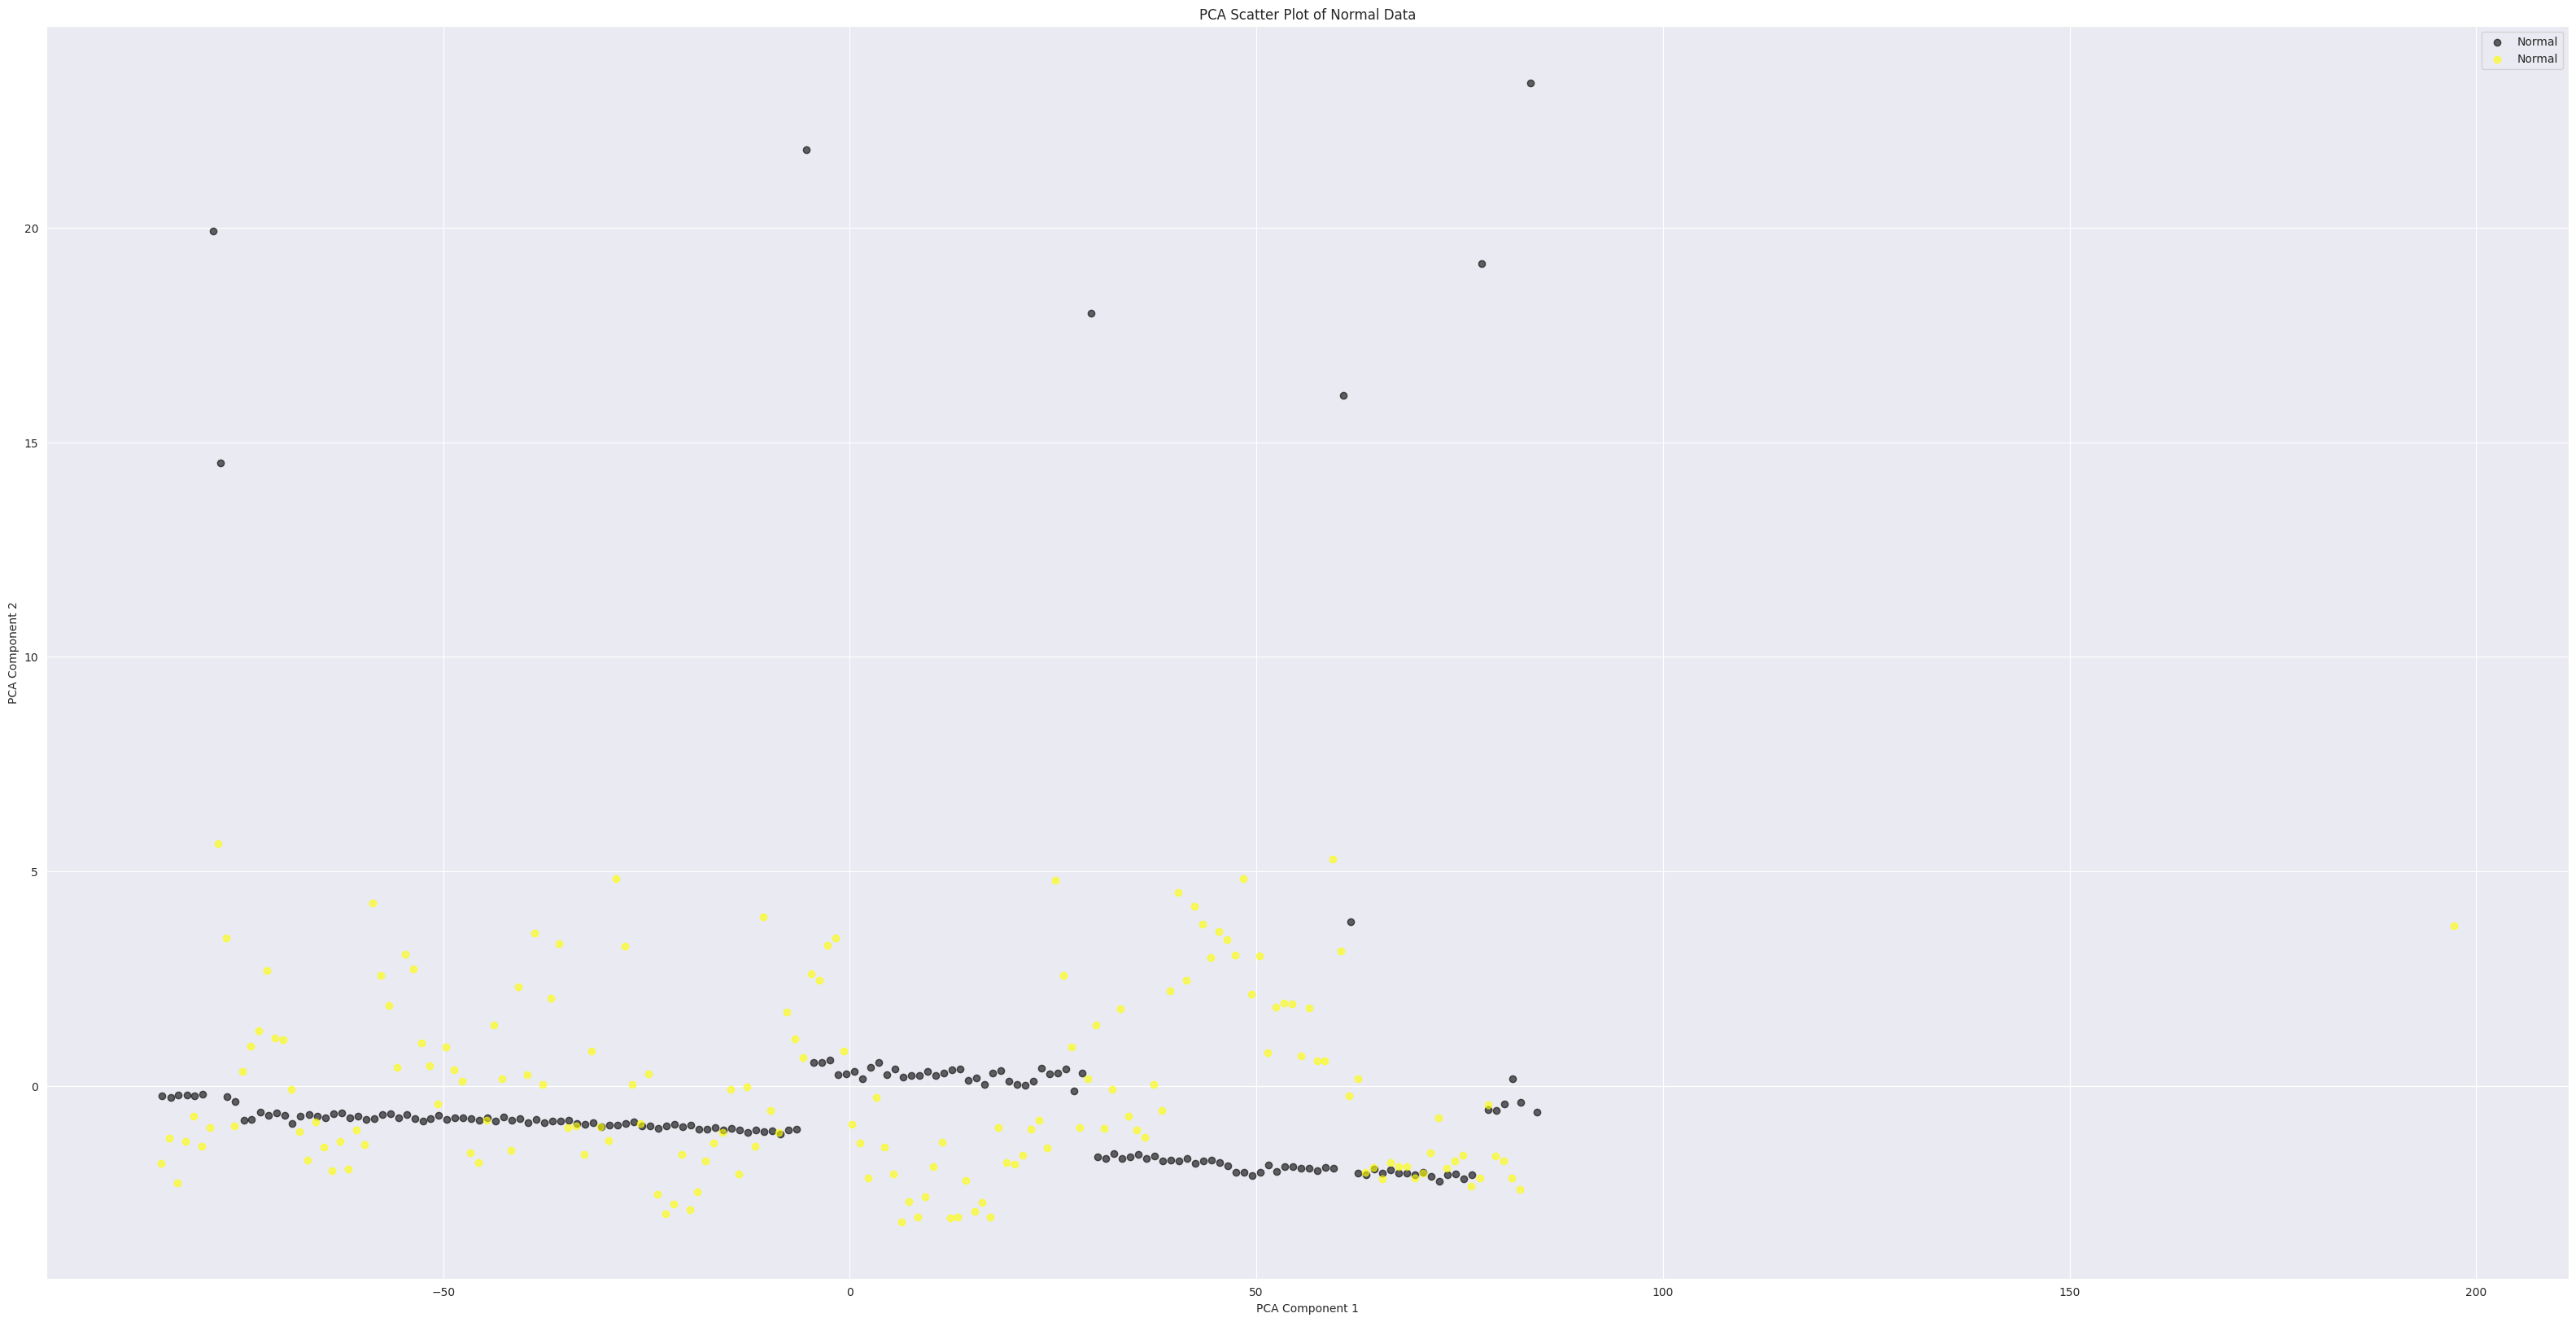

In [9]:

plt.figure(figsize=(40,20))
plt.scatter(normal[:, 0], normal[:, 1], alpha=0.6, label="Normal", color='black')
plt.scatter(anomalies[:, 0], anomalies[:, 1], alpha=0.6, label="Normal", color='yellow')
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Scatter Plot of Normal Data")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
!pip install plotly
import plotly.graph_objects as go
from sklearn.decomposition import PCA

# Apply PCA with 3 components
pca = PCA(n_components=3)
normal_3d = pca.fit_transform(normal_data[columns])
anomalies_3d = pca.transform(data[columns])  # Only transform, do NOT fit again

# Create Plotly scatter plot
fig = go.Figure()

# Add normal points
fig.add_trace(go.Scatter3d(
    x=normal_3d[:, 0],
    y=normal_3d[:, 1],
    z=normal_3d[:, 2],
    mode='markers',
    marker=dict(size=4, color='orange'),
    name='Normal'
))

# Add anomaly points
fig.add_trace(go.Scatter3d(
    x=anomalies_3d[:, 0],
    y=anomalies_3d[:, 1],
    z=anomalies_3d[:, 2],
    mode='markers',
    marker=dict(size=4, color='yellow'),
    name='Anomalies'
))

# Customize layout
fig.update_layout(
    title='3D PCA Scatter Plot (Interactive)',
    scene=dict(
        xaxis_title='PCA Component 1',
        yaxis_title='PCA Component 2',
        zaxis_title='PCA Component 3'
    ),
    width=1000,
    height=700,
    legend=dict(x=0, y=1)
)

fig.show()


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

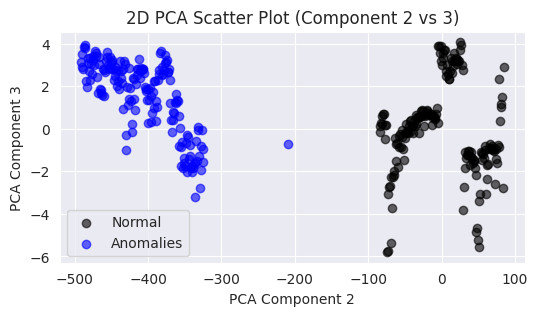

In [11]:
import matplotlib.pyplot as plt

# Plot PCA Component 2 (index 1) vs Component 3 (index 2)
plt.figure(figsize=(6, 3))

# Plot normal points
plt.scatter(normal_3d[:, 0], normal_3d[:, 2],
            alpha=0.6, label="Normal", color='black')

# Plot anomaly points
plt.scatter(anomalies_3d[:, 0], anomalies_3d[:, 2],
            alpha=0.6, label="Anomalies", color='blue')

# Labeling
plt.xlabel("PCA Component 2")
plt.ylabel("PCA Component 3")
plt.title("2D PCA Scatter Plot (Component 2 vs 3)")
plt.legend()
plt.grid(True)
plt.show()


# df

### making a pipeline

In [12]:
from model import load_data
train_df, test_df = load_data('Wind Farm C/datasets/79.csv',anomaly=True, event_start=52704, event_end=52992, plot_status_type=False,scaled=False )

/home/kashif/Desktop/III SEM/ML/Machine_learning__SS/utils.py:286: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/home/kashif/Desktop/III SEM/ML/Machine_learning__SS/utils.py:285: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/home/kashif/Desktop/III SEM/ML/Machine_learning__SS/utils.py:286: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented 

In [13]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
from CARE import CAREScore

def evaluate_model_with_care_score(train_df, test_df, anomaly_start, anomaly_end, beta=0.5, early_weight=2.0, plot_CM=False):
    # Step 1: Select relevant columns
    columns = train_df.columns.difference(['train_test', 'time_stamp', 'asset_id', 'point_of_interest'])

    # Step 2: Train KMeans
    model = KMeans(n_clusters=2, random_state=42)
    model.fit(train_df[columns])

    # Step 3: Predict and align labels
    preds = model.predict(test_df[columns])
    train_mean = train_df[columns].mean().values
    distances = [np.linalg.norm(center - train_mean) for center in model.cluster_centers_]
    normal_cluster = distances.index(min(distances))
    y_pred = np.array([0 if label == normal_cluster else 1 for label in preds])

    # Step 4: Ground truth
    y_true = test_df['point_of_interest'].values

    # Step 5: Compute confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    if plot_CM:
        cm = np.array([[tn, fp], [fn, tp]])
        labels = ['Normal (0)', 'Anomaly (1)']
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=labels, yticklabels=labels)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.tight_layout()
        plt.show()

    # Step 6: Map index labels to positions (if needed)
    start_pos = test_df.index.get_loc(anomaly_start)
    end_pos = test_df.index.get_loc(anomaly_end)

    # Step 7: CARE Score calculation
    care = CAREScore(beta=beta, early_weight=early_weight)
    coverage_fbeta = care.f_beta(tp, fp, fn)
    accuracy_score = care.accuracy(tn, fp)
    earliness_score = care.weighted_earliness(y_pred, start_pos, end_pos)
    tp_events = 1 if any(y_true[start_pos:end_pos+1]) and any(y_pred[start_pos:end_pos+1]) else 0
    fp_events = 1 if not any(y_true[start_pos:end_pos+1]) and any(y_pred[start_pos:end_pos+1]) else 0
    fn_events = 1 if any(y_true[start_pos:end_pos+1]) and not any(y_pred[start_pos:end_pos+1]) else 0
    reliability_fbeta = care.event_f_beta(tp_events, fp_events, fn_events)
    care_score = care.compute_care(coverage_fbeta, accuracy_score, reliability_fbeta, earliness_score)

    return {
        'CARE Score': care_score.item(),
        'Coverage F-beta': coverage_fbeta.item(),
        'Accuracy': accuracy_score.item(),
        'Reliability F-beta': reliability_fbeta,
        'Earliness': earliness_score.item()
    }


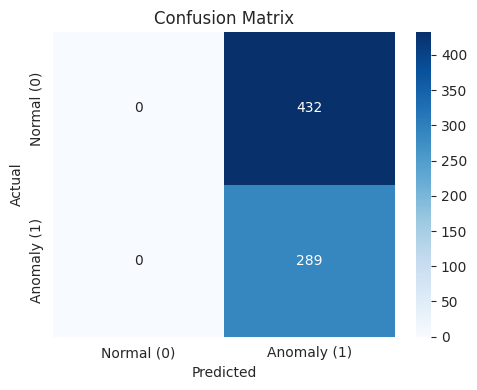

{'CARE Score': 0.0,
 'Coverage F-beta': 0.4554049795146549,
 'Accuracy': 0.0,
 'Reliability F-beta': 1.0,
 'Earliness': 1.0}

In [14]:
result = evaluate_model_with_care_score(
    train_df=train_df,
    test_df=test_df,
    anomaly_start=52704,  # this is an index label (not position)
    anomaly_end=52992,
    plot_CM=True
)

result
